# Analisis de datos del Titanic

## 1. Cargando datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:
# lectura de datos en Python
train = pd.read_csv('./../titanic/train.csv')
test = pd.read_csv('./../titanic/test.csv')

In [ ]:
train.head()

## 2. Explorando Datos

In [ ]:
# que columnas tienen los datos? 
train.columns

In [ ]:
# que tamaño tienen los datos?
train.shape

In [73]:
# hay valores nulos en os datos ? 
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [72]:
# Como se distribuyen las variables numéricas
train.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [74]:
# como se comportan las variables categóricas 
train.describe(include=['O'])

C:\Users\Lucci\AppData\Local\Temp\ipykernel_18068\2309762937.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include=['O'])


,Name,Ticket,Cabin,Embarked
count,891,891,204,889
unique,891,681,147,3
top,"Braund, Mr. Owen Harris",347082,G6,S
freq,1,7,4,644


## 2.1 EDA: Estudio de variable Target 

In [75]:
train.groupby(['Survived']).count()['PassengerId']

Survived
0    549
1    342
Name: PassengerId, dtype: int64

In [ ]:
# target vs sex
train.groupby(['Survived', 'Sex']).count()['PassengerId']

Survived  Sex
0         0      468
          1       81
1         0      109
          1      233
Name: PassengerId, dtype: int64


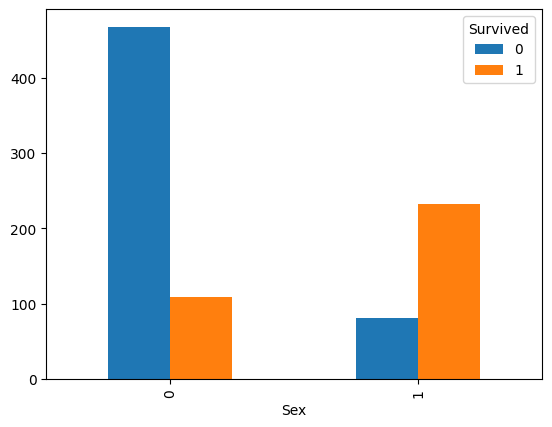

In [76]:
group_sex = train.groupby(['Survived', 'Sex']).count()['PassengerId']
print(group_sex)
(group_sex.unstack(level=0).plot.bar())
plt.show()

Axes(0.125,0.11;0.775x0.77)


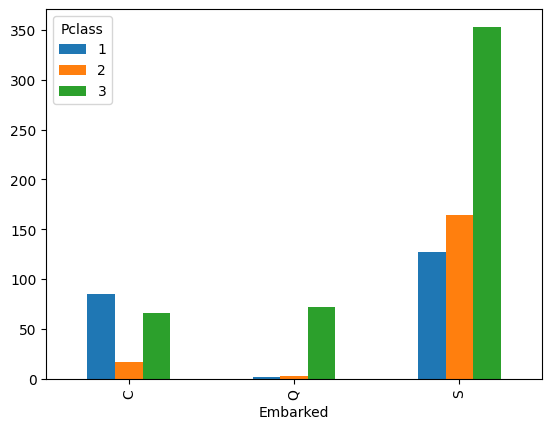

In [77]:
# embarked vs pclass
print(train.groupby(['Pclass', 'Embarked'])
                    .count()['PassengerId']
                    .unstack(level=0)
                    .plot.bar())

## 3.Procesamiento de datos 

Seleccionamos las variables con las que trabajaremos :
- Survived
- Sex
- Age
- Pclass

In [ ]:
train[['Survived', 'Sex', 'Age', 'Pclass']].head(3)

In [78]:
# Estudiamos los datos nulos
train[['Survived', 'Sex', 'Age', 'Pclass']].info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   Pclass    891 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 28.0 KB


---

Resultados a mejorar

- Datos faltantes en Age ```train['Age'].isna()```
- La variable Sex aparece como object y queremos int o float para algoritmos


---

In [ ]:
# mirar como se distribuyen los nulos de edad

(train[train['Age'].isna()]
                   .groupby(['Sex', 'Pclass'])
                   .count()['PassengerId']
                   .unstack(level=0))

In [ ]:
(train[train['Age'].isna()]
                   .groupby(['SibSp', 'Parch'])
                   .count()['PassengerId']
                   .unstack(level=0))

De arriba se concluye que era gente que viajaba mayoritarianmente sola y la mayoría eran de 3era clase 

Eso nos da la idea de que se puede crear una variable que indique si la persona viajaba sola o acompañada 

In [ ]:
#calcular la media de edad para imputar
train ['Age'].median()

In [79]:
# imputar valores para rellenar nulos 
train ['Age'] = train['Age'].fillna(28.0)
train[['Survived', 'Sex', 'Age', 'Pclass']].info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   Pclass    891 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 28.0 KB


In [ ]:
# Pasamos 'Sex' a tipo Integer

train['Sex'] = train['Sex'].map({'female': 1, 'male':0}).astype(int)

In [ ]:
# Lista procesada

In [ ]:
train[['Survived', 'Sex', 'Age', 'Pclass']].head(3)